### Assignment 1 on Intensity Transformations and Neighborhood Filtering

In [2]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

### Question 1

In [ ]:
img_orig = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img_orig is not None, "Image not found. Please check the path."

def get_gamma(gamma):
    return np.array([((i / 255.0) ** gamma) * 255 for i in range(256)], dtype=np.uint8)

In [13]:
gamma_05 = get_gamma(0.5)
gamma_20 = get_gamma(2.0)

img_gamma_05 = cv.LUT(img_orig, gamma_05)
img_gamma_20 = cv.LUT(img_orig, gamma_20)

In [ ]:
def contrast_stretching(image, r1=0.2, r2=0.8):
    # 1. Normalize image to [0, 1] if it is in uint8 (0-255)
    r = image.astype(float) / 255.0
    
    # 2. Apply the piecewise formula
    s = (r - r1) / (r2 - r1)
    
    # Values < r1 will result in s < 0 -> clipped to 0
    # Values > r2 will result in s > 1 -> clipped to 1
    s = np.clip(s, 0, 1)
    
    # 3. Convert back to uint8 (0-255) for display/saving
    output = (s * 255).astype(np.uint8)
    
    return output

r1_val = 0.2
r2_val = 0.8

# Apply transformation
img_stretch = contrast_stretching(img_orig, r1=r1_val, r2=r2_val)

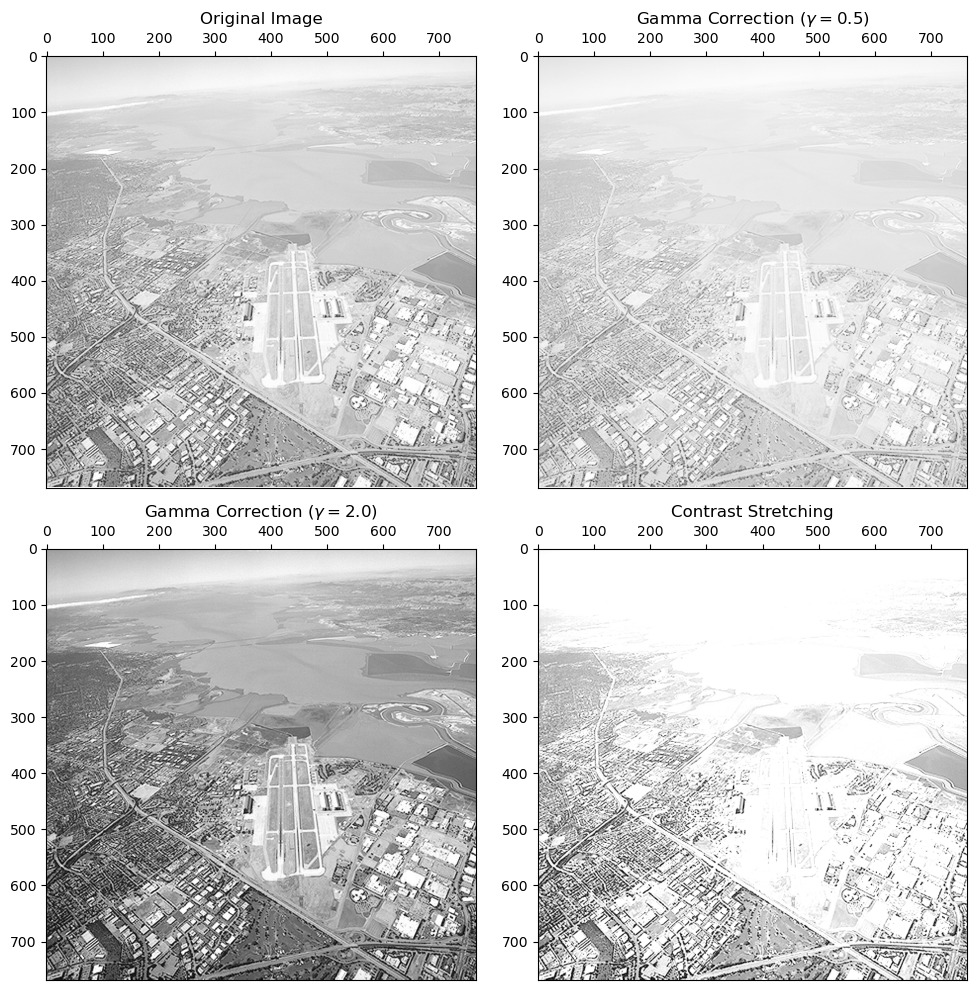

In [17]:
fig, ax = plt.subplots(2, 2, figsize=(10, 10))

# Original
ax[0, 0].imshow(img_orig, cmap='gray', vmin=0, vmax=255)
ax[0, 0].set_title('Original Image')
ax[0, 0].xaxis.set_ticks_position('top')

# Gamma 0.5
ax[0, 1].imshow(img_gamma_05, cmap='gray', vmin=0, vmax=255)
ax[0, 1].set_title(r'Gamma Correction ($\gamma=0.5$)')
ax[0, 1].xaxis.set_ticks_position('top')

# Gamma 2.0
ax[1, 0].imshow(img_gamma_20, cmap='gray', vmin=0, vmax=255)
ax[1, 0].set_title(r'Gamma Correction ($\gamma=2.0$)')
ax[1, 0].xaxis.set_ticks_position('top')

# Contrast Stretching
ax[1, 1].imshow(img_stretch, cmap='gray', vmin=0, vmax=255)
ax[1, 1].set_title('Contrast Stretching')
ax[1, 1].xaxis.set_ticks_position('top')

plt.tight_layout()
plt.show()

### Question 2

C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\56504838.py:27: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(l_channel.ravel(), 256, [0, 256], color='black')
C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\56504838.py:32: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.hist(l_corrected.ravel(), 256, [0, 256], color='blue')


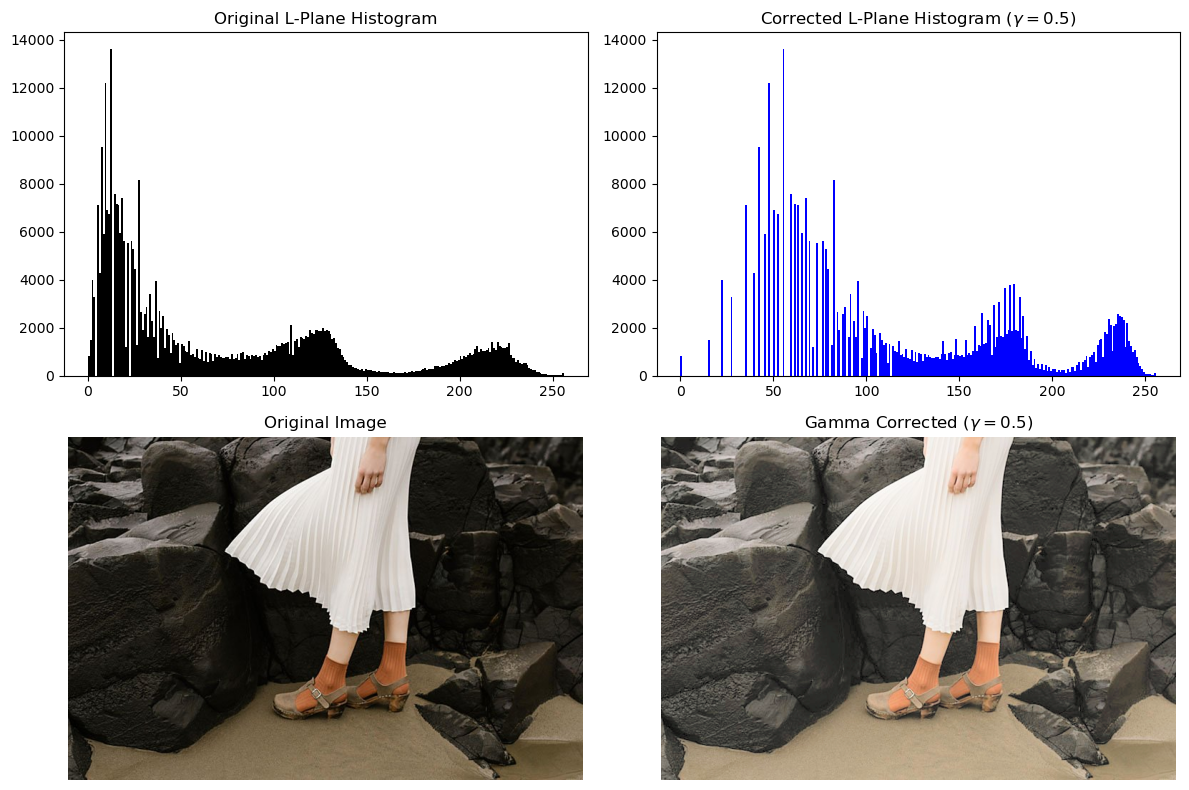

In [ ]:
img = cv.imread('images/highlights_and_shadows.jpg')

assert img is not None, "Image not found. Please check the path."

lab = cv.cvtColor(img, cv.COLOR_BGR2LAB)
l_channel, a_channel, b_channel = cv.split(lab)

# 3. Apply Gamma Correction to the L plane
# Normalize L channel to [0, 1] for calculation
l_normalized = l_channel.astype(np.float32) / 255.0
gamma = 0.5  # Example gamma value for brightening
l_gamma = np.power(l_normalized, gamma)

# Scale back to [0, 255]
l_corrected = (l_gamma * 255).astype(np.uint8)
# 4. Merge channels back and convert to RGB for display
lab_corrected = cv.merge([l_corrected, a_channel, b_channel])
corrected_img = cv.cvtColor(lab_corrected, cv.COLOR_LAB2RGB)
original_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.figure(figsize=(12, 8))

# Original L Histogram
plt.subplot(2, 2, 1)
plt.title("Original L-Plane Histogram")
plt.hist(l_channel.ravel(), 256, [0, 256], color='black')

# Corrected L Histogram
plt.subplot(2, 2, 2)
plt.title(f"Corrected L-Plane Histogram ($\gamma={gamma}$)")
plt.hist(l_corrected.ravel(), 256, [0, 256], color='blue')

# Visual Comparison
plt.subplot(2, 2, 3)
plt.title("Original Image")
plt.imshow(original_rgb)
plt.axis('off')

plt.subplot(2, 2, 4)
plt.title(f"Gamma Corrected ($\gamma={gamma}$)")
plt.imshow(corrected_img)
plt.axis('off')

plt.tight_layout()
plt.show()

### Question 3

C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\607575361.py:29: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2, 2, 3); plt.hist(img.flatten(), 256, [0,256]); plt.title("Original Hist")
C:\Users\Neths\AppData\Local\Temp\ipykernel_11540\607575361.py:30: MatplotlibDeprecationWarning: Passing the range parameter of hist() positionally is deprecated since Matplotlib 3.9; the parameter will become keyword-only in 3.11.
  plt.subplot(2, 2, 4); plt.hist(equalized_img.flatten(), 256, [0,256]); plt.title("Equalized Hist")


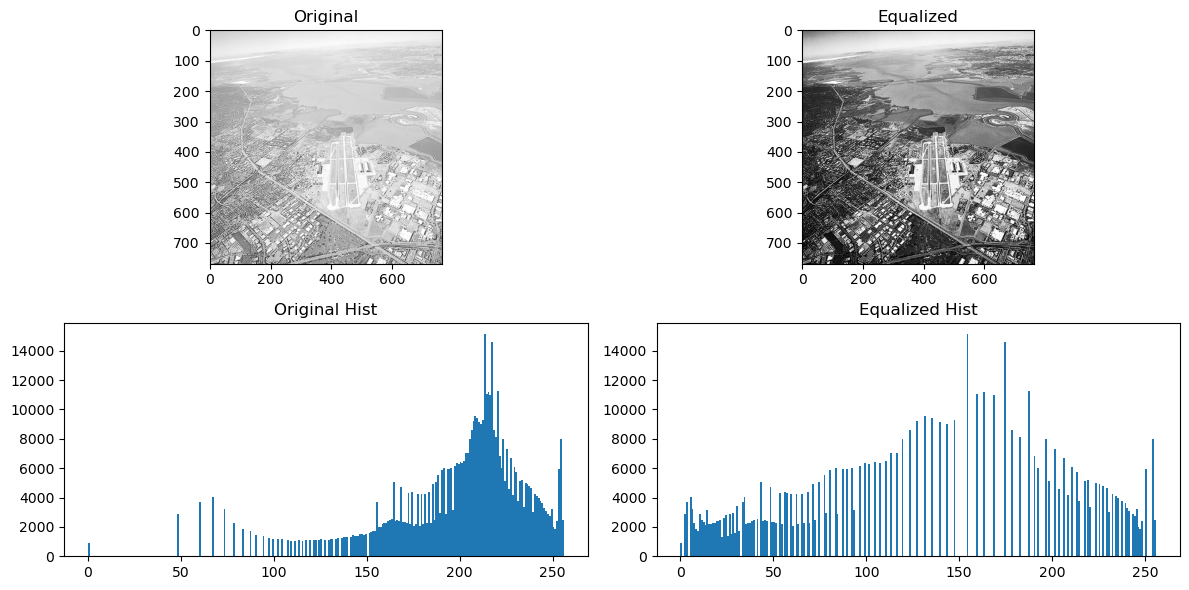

In [ ]:
def histogram_equalization(image):
    # 1. Get image dimensions M (height) and N (width)
    M, N = image.shape[:2]
    L = 256  # Total intensity levels
    
    # 2. Calculate the histogram (frequency of each intensity n_j)
    hist, bins = np.histogram(image.flatten(), L, [0, L])
    
    # 3. Calculate the Cumulative Sum (running total of n_j)
    cumulative_sum = hist.cumsum()
    
    # 4. Apply the formula: s_k = (L-1 / MN) * cumulative_sum
    transformation_factor = (L - 1) / (M * N)
    s_k = np.round(cumulative_sum * transformation_factor).astype('uint8')
    
    # 5. Map the original image pixels (r_k) to the new values (s_k)
    equalized_image = s_k[image]
    
    return equalized_image

img = cv.imread('images/runway.png', cv.IMREAD_GRAYSCALE)
assert img is not None, "Image not found. Please check the path."

equalized_img = histogram_equalization(img)

plt.figure(figsize=(12, 6))
plt.subplot(2, 2, 1); plt.title("Original"); plt.imshow(img, cmap='gray')
plt.subplot(2, 2, 2); plt.title("Equalized"); plt.imshow(equalized_img, cmap='gray')
plt.subplot(2, 2, 3); plt.hist(img.flatten(), 256, [0,256]); plt.title("Original Hist")
plt.subplot(2, 2, 4); plt.hist(equalized_img.flatten(), 256, [0,256]); plt.title("Equalized Hist")
plt.tight_layout()
plt.show()